# UGST4012 - Digital Tools for the Social Sciences 
## Central European University, Winter 2020/2021
## LABS 3: Pre-processing text data
Author: Gabriela Juncosa,  PhD

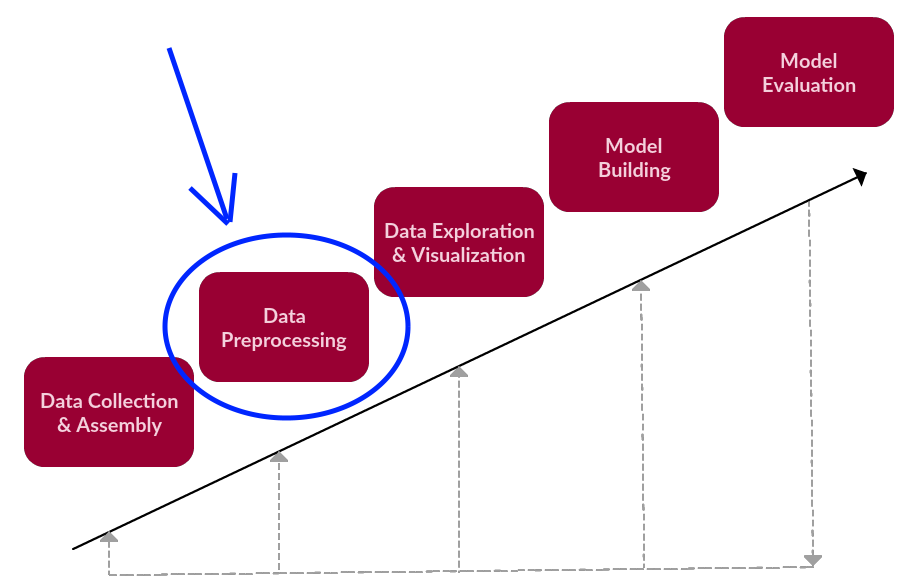

In [2]:
from IPython.display import Image
Image(filename='text-data-task-framework-preprocessing.png',width=1100)

### Introduction to text data pre-processing

To preprocess your text simply means to bring your text into a form that is predictable and analyzable for your task. A task here is a combination of approach and domain. One task’s ideal preprocessing can become another task’s worst nightmare. So take note: text preprocessing is not directly transferable from task to task.

Let’s take a very simple example, let’s say you are trying to discover commonly used words in a news dataset. If your pre-processing step involves removing stop words because some other task used it, then you are probably going to miss out on some of the common words as you have ALREADY eliminated it. So really, it’s not a one-size-fits-all approach.


SOURCE: https://www.kdnuggets.com/2019/04/text-preprocessing-nlp-machine-learning.html#:~:text=What%20is%20text%20preprocessing%3F,an%20example%20of%20a%20Task.

### Pre-processing steps to cover:

        1. Lowercasing 
        2. Remove punctuation 
        3. Tokenization
        4. Remove stopwords 
        5. Lemmatization and/or stemming 
        7. Text normalization 

SOURCE: https://www.kaggle.com/ragnisah/text-data-cleaning-tweets-analysis

--------------------

## 1. Upload libraries 

If you get an error message while uploading your library that says the library hasn't been found, use the following two lines of code to install new libraries. 

import sys

!{sys.executable} -m pip install (LIBRARY_NAME)

In [3]:
# example of how to install tweepy, the library we'll use to connet to Twitter's API
#import sys
#!{sys.executable} -m pip install tweepy

In [5]:
from IPython.display import Image
#import tweepy
import json
import os
import pandas as pd

In [8]:
os.getcwd()

'/usr/local/bin/PhD notebooks GT/UGST4012/LAB3'

In [11]:
# always check where your working directory and make sure it's set to the correct directory
 # this is your current working directory 
os.chdir('/usr/local/bin/PhD notebooks GT/UGST4012/LAB3') # use this code if you need to change the working directory

In [12]:
os.getcwd()

'/usr/local/bin/PhD notebooks GT/UGST4012/LAB3'

## 2. Review: how to download data from Twitter  
### Data collection and Assembly 

Twitter is an online news and social networking service where users post and interact with messages, "tweets," restricted to 280 characters. Registered users can post tweets, and those who are unregistered can only read them.

### A tweet can contain:
* #hashtag - keywords 
* @mentions - direct citation to other users
* url information
* location information (not default since 2019 july)
* number of retweets
* Number of likes

### For this code you will need: 
- API_KEY
- API_SECRET
- TOKEN_KEY (called costumer key)
- TOKEN_SECRET (called costumer secret)

#### These can be found on the "Keys and Access Tokens" page

### Save the keys in a file e.g. called "oauth.keys" with the format:
    
API_KEY ...  
API_SECRET ...  
TOKEN ...  
TOKEN_SECRET ...

### OR store them as variables in the cell below:

In [6]:
# Run this cell if you don't have the "oauth.keys" file 

#API_KEY = '45465465'
#API_SECRET = 'your_access_secret'
#TOKEN = 'your_consumer_key'
#TOKEN_SECRET = 'your_consumer_secret'

In [5]:
# Run this cell if you do have the "oauth.keys" file 

oauth_dict={}
for line in open('oauth.keys','r'):
    data=list(map(str,line.split()))
    oauth_dict[data[0]]=data[1]

## 2.1 Connect to the OAuth interface

- Twitter uses the OAuth interface to identify an application to access the API.
- It takes an OAuth instance as argument and returns a Twitter object that we can use to interact with the API

In [6]:
# recall we imported the twitter library as import tweepy, this determines how we will call the library functions

auth = tweepy.OAuthHandler(oauth_dict['API_KEY'], oauth_dict['API_SECRET'])
auth.set_access_token(oauth_dict['TOKEN'], oauth_dict['TOKEN_SECRET'])

api = tweepy.API(auth) # connect to the API

In [7]:
# ONLY RUN THIS CELL IF YOU WERE UNABLE TO RUN THE CELL BEFORE!!! 
#auth = tweepy.OAuthHandler(API_KEY, API_SECRET)
#auth.set_access_token(TOKEN, TOKEN_SECRET)

#api = tweepy.API(auth) # connect to the API

## 2. 2 Download the relevant twitter objects

### We will download an users' timeline, for this we need the users' handle 

To download a users' timeline, your first have to call the service which we call `api` in the cell before, then we call the specific object, in our case `user_timeline`. The `user_timeline` command returns the 20 most recent statuses posted from the authenticating user or the user specified. It’s also possible to request another user’s timeline via the id parameter. For reference see: https://docs.tweepy.org/en/v3.5.0/api.html

For more information on Tweepy go to : https://www.tweepy.org/

In [11]:
VPharris_tweets = api.user_timeline('cnnbrk', count = '3000', page=page)

NameError: name 'page' is not defined

In [12]:
import tweepy
import json
import pandas as pd


auth = tweepy.OAuthHandler(oauth_dict['API_KEY'], oauth_dict['API_SECRET'])
auth.set_access_token(oauth_dict['TOKEN'], oauth_dict['TOKEN_SECRET'])

api = tweepy.API(auth) # connect to the API

results=[]

timeline = tweepy.Cursor(api.user_timeline, screen_name='@cnnbrk', tweet_mode="extended").items()

for status in timeline:
    data = (
    status.user.id,
    status.user.screen_name,
    status.user.name,
    status.full_text,
    status.created_at,
    status.lang)
    results.append(data)

cols = "user_id screen_name name text date lang".split()
df = pd.DataFrame(results, columns=cols)

In [14]:
# why type of object is it?
df.shape

(1940, 6)

In [16]:
# how many tweets fo we have access to? 
print('There are', len(VPharris_tweets), 'tweets')

There are 20 tweets


In [17]:
# wanna get more than 20???
test = tweepy.Cursor(api.user_timeline, id="twitter")

#### The for statement

We will print each downloaded tweet using a `for` loop. A `for` loop is used for iterating over a sequence.

With the `for` loop we can execute a set of statements, once for each item in a list, tuple, set etc. 



<code>
for_stmt ::=  "for" target_list "in" expression_list ":" suite
                 ["else" ":" suite]
</code>

In [19]:
num = [1, 2, 3, 4, 5]
for n in num: 
    print(n)

1
2
3
4
5


In [16]:
VPharris_tweets[0].text

'RT @POTUS: The fight against cancer is personal for me, like it is for so many Americans. And I’m committed to doing everything I can as pr…'

In [18]:
for tweet in VPharris_tweets:
    print(tweet.text)

Congratulations to our new Secretary of State, Antony Blinken. @SecBlinken will revitalize American diplomacy, adva… https://t.co/LRXL71Tdwt
Across the world, climate change poses an existential threat not only to our environment – but to our health, our c… https://t.co/Cjaq4AMcxL
One week on the job: we took action on COVID, the economy, the climate crisis, racial injustice – and more.

The wo… https://t.co/BXufQiq7Tq
RT @POTUS: We have no time to waste when it comes to tackling the threat of climate change. That’s why today, I’ll be taking action to addr…
President Biden and I will continue to stand up to hatred in all forms and do everything we can to prevent future g… https://t.co/xlHCPGWwxi
When Douglas and I visited Yad Vashem in Israel a few years ago, it was a powerful reminder of what happens when we… https://t.co/RNjqAm9U0P
And we pledge to stay vigilant and teach our children, and their children, the truth about the horrors of the Holoc… https://t.co/768XScmi4S
In honoring t

# 2. 3 Organize the data into a dataframe 
For this step we will use the Pandas lybrary, which provides high-performance, easy-to-use data structures and data analysis tools. For more information refer to: https://pandas.pydata.org/pandas-docs/stable/index.html. 

To do so, we will first store the relevant pieces of information as lists. We're interested on:
1. Tweet Id 
2. Tweet text 
3. Favorite count 
4. Retweet count 
5. Time when tweet was created 

In [17]:
# Define empty lists for each piece of information 
tweet_id = []
text = []
favorite_count = []
retweet_count = []
created_at = []

In [18]:
print(len(tweet_id))

0


In [19]:
for tweet in VPharris_tweets:
    tweet_id.append(tweet.id)
    text.append(tweet.text)
    favorite_count.append(tweet.favorite_count)
    retweet_count.append(tweet.retweet_count)
    created_at.append(tweet.created_at)

In [20]:
print(len(tweet_id))

20


In [23]:
print(tweet_id)

[1354582563164139520, 1354557611748765697, 1354510467918667784, 1354489791623159810, 1354486618518937609, 1354486616514039811, 1354486614773391362, 1354486613083107333, 1354486611384401922, 1354261671469051909, 1354234432207642624, 1354155825594560515, 1354127313508724737, 1353784403026128897, 1353757741777616896, 1353757532267962371, 1353368375729283073, 1353352962287034370, 1353087016007839745, 1353066572634497032]


In [21]:
# check the length is the same for all lists
print(len(tweet_id), len(text), len(favorite_count), len(retweet_count), len(created_at))

20 20 20 20 20


In [27]:
# another way to access the tweets
VPharris_tweets[0].id

1354582563164139520

### Creating a Pandas dataframe 
There are multiple ways to create a Pandas dataframe, here we will call the DataFrame constructor after zipping all five lists, and then specify the column names. For further information about this method check https://www.geeksforgeeks.org/create-a-pandas-dataframe-from-lists/

In [26]:
df_tweets = pd.DataFrame(list(zip(tweet_id, text, favorite_count, retweet_count, created_at)), 
               columns =['ID', 'text', 'favoriteCount', 'retweetCount', 'createdAt']) 

In [24]:
df_tweets = pd.DataFrame(list(zip(tweet_id, text, favorite_count, retweet_count, created_at))) 

In [27]:
df_tweets

,ID,text,favoriteCount,retweetCount,createdAt
0,1367494848505384965,RT @POTUS: The fight against cancer is persona...,0,3219,2021-03-04 15:19:13
1,1367482915765039109,"Last night, the House voted to pass H.R. 1. @P...",15188,1840,2021-03-04 14:31:48
2,1367266314948116483,"This afternoon, I swore in Gina Raimondo as Se...",15187,1559,2021-03-04 00:11:06
3,1367209538005401611,I enjoyed visiting Danielle and her team today...,15792,1774,2021-03-03 20:25:30
4,1367206249666916361,"RT @POTUS: On February 15, my Administration o...",0,4498,2021-03-03 20:12:26
5,1366936585720242177,Today I spoke with Prime Minister @ScottMorris...,17284,1679,2021-03-03 02:20:53
6,1366903129489502210,Congratulations to our new Secretary of Educat...,22645,2273,2021-03-03 00:07:56
7,1366883478348906501,My heart goes out to the family of my friend a...,27509,2380,2021-03-02 22:49:51
8,1366866135858167812,"RT @POTUS: Three weeks ago, I announced we wou...",0,25949,2021-03-02 21:40:56
9,1366857091965726722,"On this day, in 1867, my alma mater @HowardU w...",10921,1239,2021-03-02 21:05:00


In [30]:
df_tweets.head()

,ID,text,favoriteCount,retweetCount,createdAt
0,1354582563164139520,"Congratulations to our new Secretary of State,...",51995,4115,2021-01-28 00:10:24
1,1354557611748765697,"Across the world, climate change poses an exis...",10941,1378,2021-01-27 22:31:15
2,1354510467918667784,"One week on the job: we took action on COVID, ...",58543,4583,2021-01-27 19:23:55
3,1354489791623159810,RT @POTUS: We have no time to waste when it co...,0,10846,2021-01-27 18:01:46
4,1354486618518937609,President Biden and I will continue to stand u...,11215,997,2021-01-27 17:49:09


In [28]:
# save Pandas dataframe as a csv file 
df_tweets.to_csv(r'VP_KHarris_tweets.csv')

## 3. Pre-processing text data 

1. Remove punctuation 
2. Tokenization
3. Remove stopwords 
4. Lemmatization and/or stemming  

## 3.1 Pre-processing text data: remove punctuation

In [32]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [33]:
# choose first tweet as example 
text = VPharris_tweets[0].text
print(text)

Congratulations to our new Secretary of State, Antony Blinken. @SecBlinken will revitalize American diplomacy, adva… https://t.co/LRXL71Tdwt


In [34]:
# remove punctuation
text  = "".join([char for char in text if char not in string.punctuation])
print(text)
# can you spot the issue with this removal?

Congratulations to our new Secretary of State Antony Blinken SecBlinken will revitalize American diplomacy adva… httpstcoLRXL71Tdwt


In [ ]:
# remove numbers
import re
text = re.sub('[0-9]+', '', text)
print(text)
# is there a potential issue with this removal?

In [ ]:
# now let's run this through a loop 
tweet_punct = []
for tweet in VPharris_tweets:
    text = tweet.text
    text  = "".join([char for char in text if char not in string.punctuation])
    text = re.sub('[0-9]+', '', text)
    tweet_punct.append(text)

df_tweets['tweetPunct'] = tweet_punct
df_tweets.head()

## 3.2 Pre-processing text data: tokenization

In [ ]:
text = VPharris_tweets[0].text
print(text)

In [ ]:
text = re.split('\W+', text)
print(text)

In [ ]:
# now let's run this through a loop 
tweet_token = []
for tweet in VPharris_tweets:
    text = tweet.text
    text = re.split('\W+', text)
    tweet_token.append(text)

df_tweets['tweetToken'] = tweet_token
df_tweets.head()